# Survival Analysis on the MIMIC Dataset

We consider a longitudinal clinical dataset extracted from the MIMIC database.  
Each patient is associated with several chronological medical reports collected during the follow-up period.

The dataframe contains the following variables:

- `'SUBJECT_ID'`: Unique identifier of a patient. A single patient may have several associated observations (clinical reports).
- `'note_time'`: Datetime $t_j$ corresponding to the $j$-th clinical report of a patient.
- `'embeddings'`:  Sentence embedding extracted from the clinical report. These embeddings are obtained using a biomedical NLP model followed by a SIF aggregation procedure applied to contextual word embeddings. Each embedding is represented as a vector in
  $\mathbb{R}^p$, where typically $p = 768$.
- `'delta_i'`: Event indicator associated with patient $i$. It's formally written as:
  $$
  \delta_i =
  \begin{cases}
  1 & \text{if the event is observed (death)}, \\
  0 & \text{if the patient is censored.}
  \end{cases}
  $$

- `'survival_time'` (or $T_i$): Observed survival time of patient $i$, expressed in days.
- `'time_since_first_note'`: Relative time elapsed since the first available report of the patient.
- `'death_time'`: Datetime of death if the event occurred. This variable is equal to `NaN` for censored patients.

The objective is to transform the sequential trajectory of embeddings into meaningful covariates for survival analysis using the SigBERT pipeline:
1. temporal normalization,
2. path construction,
3. signature feature extraction,
4. Cox proportional hazards modeling.

In [1]:
import types
import sys
from numbers import Real, Integral

# Create a fake module to emulate 'sklearn.utils._param_validation'
# (used by skglm in newer versions of scikit-learn, >=1.3)
param_validation = types.ModuleType("sklearn.utils._param_validation")

# Define a minimal replacement for Interval used in _parameter_constraints
class Interval:
    def __init__(self, dtype, left, right, closed="neither"):
        self.dtype = dtype
        self.left = left
        self.right = right
        self.closed = closed

# Define a minimal replacement for StrOptions used in _parameter_constraints
class StrOptions:
    def __init__(self, options):
        self.options = set(options)

# Add the custom classes to the fake module
param_validation.Interval = Interval
param_validation.StrOptions = StrOptions

# Inject the fake module into sys.modules before skglm is imported
# This prevents skglm from raising an ImportError if sklearn < 1.3
sys.modules["sklearn.utils._param_validation"] = param_validation

In [2]:
import os
import sys
import time
import numpy as np
import pandas as pd
import skglm
from tqdm import tqdm

In [3]:
# Add the src directory to the Python path
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import our custom modules
from utils import *
from compression_pkg import *
from survival_analysis_sigbert import *

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

## I) Data Importation

In [5]:
df_OG = pd.read_parquet("../data/df_mimic_L36_w24.parquet", engine="pyarrow")
# df_OG = pd.read_parquet("../data/df_mimic_L36_w24.parquet", engine="pyarrow").head(1000).copy()

In [6]:
print("Total shape:", df_OG.shape)

Total shape: (456330, 10)


In [7]:
df_OG = convert_date_columns(df_OG)

In [8]:
df_OG = convert_embedding_strings(df_OG,var_embd="embeddings")

In [9]:
print_dataset_statistics(df_OG, var_id="SUBJECT_ID", var_death="delta_i")

Total number of patients in the dataset: 9644
Total number of medical reports: 456330
Average number of reports per patient: 47.32
Number of deceased patients: 3635
Number of censored patients: 6009


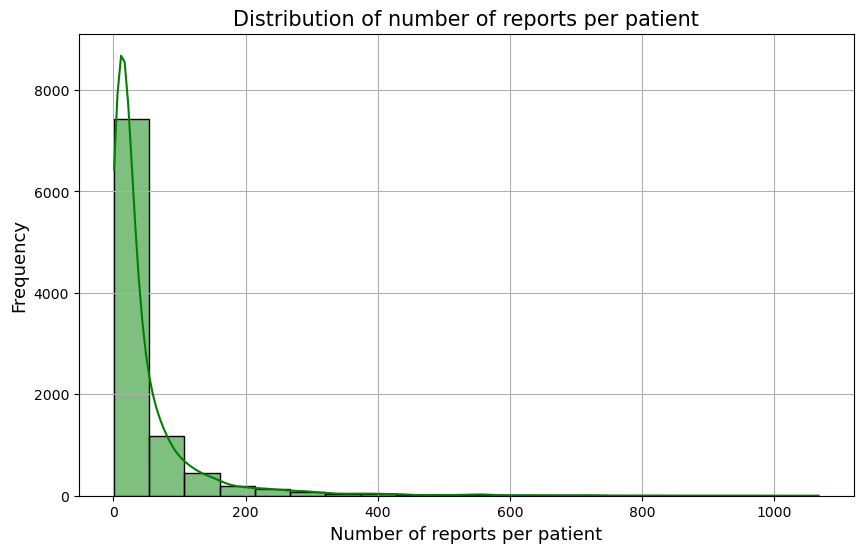

In [10]:
plot_report_distribution_per_patient(df_OG, var_id="SUBJECT_ID", export_path=None)

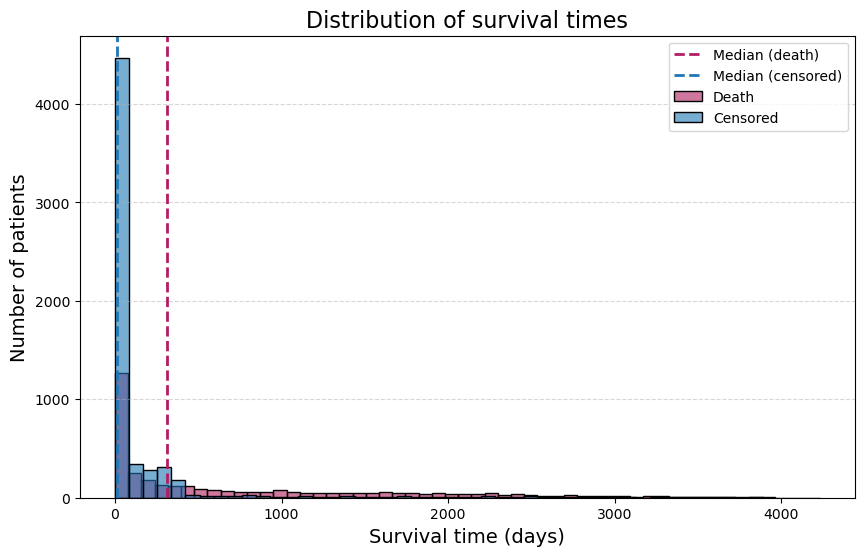

Number of unique patients: 9644
Number of deceased patients: 3635
Number of censored patients: 6009

Deceased patients
-----------------
count    3635.000000
mean      757.278680
std       925.491957
min         0.000000
25%        33.000000
50%       312.000000
75%      1301.500000
max      3963.000000
Name: survival_time, dtype: float64

Censored patients
-----------------
count    6009.000000
mean      178.126643
std       517.436110
min         0.000000
25%         2.000000
50%        12.000000
75%        91.000000
max      4230.000000
Name: survival_time, dtype: float64


In [11]:
df_patient, stats_deceased, stats_censored = plot_survival_time_distribution(df_OG)

## II) Survival Modeling

### II)1) Landmark modeling

In [12]:
df_OG.head(1)

,SUBJECT_ID,note_time,event,death_time,time_since_first_note,survival_time,report_word_count,Ti,delta_i,embeddings
0,20,2183-04-16,0,None,0,23.0,81,23.0,0,"[-0.0018343869596719742, -0.021196581423282623..."


In [13]:
L_chosen = 36; w_chosen = 24  # Adapt the landmark point and window size by yourself.

# Build the landmark cohort
df_L, patients_L, df_gamma_L = define_landmark_cohort(
    df_OG,
    landmark_months=L_chosen,
    var_time = 'note_time',
    var_id = 'SUBJECT_ID',
    var_since_start = 'time_since_first_note',
    var_T = 'Ti',
    window_months=w_chosen
)

[Landmark 36 mo] Patients kept: 1348/9644 (8296 excluded)
  → Short-history γ=1: 512/1348 = 38.0%
  → Observations kept: 13430/95472 (14.1% retained, 85.9% removed)
  → Residual survival R_i computed (min=6.0 days).
  → Landmark events computed: DEATH_L sum = 9073.


In [14]:
df_L = df_OG.copy()

In [15]:
# Count number of clinical reports in the window
df_counts = (
    df_L.groupby("SUBJECT_ID")
        .size()
        .reset_index(name="n_reports")
)
mean_reports = df_counts["n_reports"].mean()
std_reports = df_counts["n_reports"].std(ddof=1)

In [16]:
# Train-test construction
df_train_new_OG, test_groups = make_train_test(df_L, n_group=10, size_test=0.5, min_date=None, random_state=18)

Initial rows: 456330
Initial patients: 9644
Training patients: 4822
Test group 1: 483 patients
Test group 2: 483 patients
Test group 3: 482 patients
Test group 4: 482 patients
Test group 5: 482 patients
Test group 6: 482 patients
Test group 7: 482 patients
Test group 8: 482 patients
Test group 9: 482 patients
Test group 10: 482 patients


In [17]:
k_comp = 25

# PCA compression
V_proj, R_comp, mean_embedding, explained_ratio = pca_compression(df_train_new_OG, k_comp, verbose=True)

df_all = df_L.copy()

Original dimension: 768
Compressed dimension: 25
Explained variance ratio: 93.92%


In [18]:
np.allclose(df_all["survival_time"], df_all["Ti"], equal_nan=True)

True

## LASSO refit

In [19]:
lambda_l1_CV_RO = 0.1

global_lambda_results_RO = {}
results_summary_RO = []

print("\n===================================")
print(f"Running Reports Only for lambda = {lambda_l1_CV_RO}")
print("===================================")

start_pipeline = time.time()

(
    df_pipeline_results_RO,
    cph_RO,
    df_survival_RO,
    w_sk_RO,
    scores_RO,
    X_RO,
    y_train_RO,
    y_cox_RO,
    c_index_train_RO,
    c_index_test_list_RO,
    c_index_test_mean_RO,
    c_index_test_std_RO,
    df_survival_test_list_RO,
    df_test_metrics_RO,
    X_test_list_RO,
    y_test_list_RO
) = global_sigbert_mimic_pipeline(
    df_full=df_all,
    df_train=df_train_new_OG,
    test_groups=test_groups,
    projection_matrix=R_comp,
    mean_embedding=mean_embedding,
    lambda_l1=lambda_l1_CV_RO,
    signature_order=2,
    use_levy_area=False,
    print_progress=False,
    patient_id_col="SUBJECT_ID",
    embedding_col="embeddings",
    timestamp_col="note_time",
    event_col="delta_i",
    duration_col="survival_time",
    use_standard_scaling=False
)

lasso_execution_time_minutes = (time.time() - start_pipeline) / 60

# Number of covariates selected by the LASSO
non_zero_coefficients_RO = int(
    (np.abs(np.asarray(w_sk_RO)) > 1e-12).sum()
)

# Confidence interval across test groups
lower_bound_RO, upper_bound_RO = jackknife_confidence_interval(
    c_index_test_list_RO
)


Running Reports Only for lambda = 0.1

### Running SigBERT pipeline on MIMIC dataset ###
Number of test groups received: 10
Total number of patients in train set: 4209
Test group 1: 422 patients, 27355 reports
Test group 2: 425 patients, 23109 reports
Test group 3: 425 patients, 24694 reports
Test group 4: 411 patients, 23029 reports
Test group 5: 420 patients, 24385 reports
Test group 6: 442 patients, 24009 reports
Test group 7: 428 patients, 21439 reports
Test group 8: 424 patients, 20953 reports
Test group 9: 421 patients, 21217 reports
Test group 10: 414 patients, 21858 reports
Total number of patients across all test groups: 4232
Timestamps normalized for each patient to the [0, 1] range.
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 1775 out of 4209 (42.17%)

--------------- Cox training ---------------
 --------> X.shape: (4209, 702)

 --------> y.shape: (4209, 2)



/Applications/anaconda3/envs/sigbert-env/lib/python3.8/site-packages/skglm/solvers/prox_newton.py:433: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 1, 'C', False, aligned=True))
  grad[idx] = X[:, j] @ raw_grad


Number of nonzero coefficients in solution: 190 out of 702.
w_sk.shape: (702,)
---
NaNs in risk_score: 0
Infs in risk_score: 0
C-index on training data: 0.762
Execution time: 1805.35 seconds (30.09 minutes)

        Scores:
        C-index        = 0.762
        Log-likelihood = -2.81
        
--------------------------------------------

Evaluation on test group 1/10
Patients before signature: 422
Reports: 27355
Timestamps normalized for each patient to the [0, 1] range.
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 173 out of 422 (41.00%)
---
NaNs in risk_score: 0
Infs in risk_score: 0
Concordance index on test set: 0.695

Evaluation on test group 2/10
Patients before signature: 425
Reports: 23109
Timestamps normalized for each patient to the [0, 1] range.
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 175 out of 425 (41.18%)
---
NaNs in risk_score: 0
Infs in risk_score: 0
Concordance index on test set: 0.740


In [20]:
from metrics_plot_results_pkg import *

Computing Brier Scores: 100%|███████████████████| 10/10 [00:05<00:00,  1.75it/s]


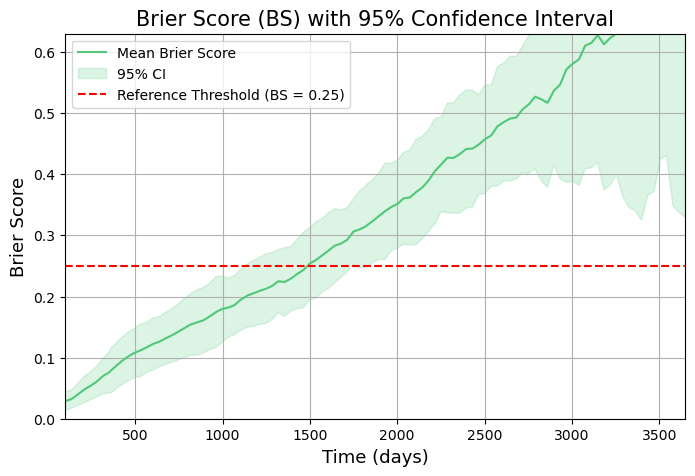


LASSO test results by group:


,Test group,Number of reports,Patients before signature,Patients evaluated,Events,Censored,C-index
0,1,27355,422,422,173,249,0.694863
1,2,23109,425,425,175,250,0.739584
2,3,24694,425,425,194,231,0.695423
3,4,23029,411,411,163,248,0.717775
4,5,24385,420,420,188,232,0.703549
5,6,24009,442,442,186,256,0.714397
6,7,21439,428,428,198,230,0.725318
7,8,20953,424,424,172,252,0.763957
8,9,21217,421,421,182,239,0.721091
9,10,21858,414,414,163,251,0.749230



Brier Score summary:


,Time horizon,Time (days),Brier Score Mean,Brier Score Std,95% CI Lower,95% CI Upper
0,1 year,365,0.0800,0.0199,0.0677,0.0924
1,2 years,730,0.1397,0.0244,0.1245,0.1548
2,3 years,1095,0.1927,0.0266,0.1763,0.2092


In [21]:
evaluation_times = np.sort(np.unique(np.concatenate((
    np.linspace(100, 3650, 100),
    [365, 730, 1095, 1825, 3650]
))))

brier_scores_array_RO, _, _, _, _ = (
    evaluate_brier_score_multiple_tests(
        df_survival_test_list=df_survival_test_list_RO,
        cph=cph_RO,
        evaluation_times=evaluation_times,
        brier_score_function=brier_score_ipcw_with_cph,
        export_fig=False,
        verbose=False
    )
)

target_times = {
    "1 year": 365,
    "2 years": 730,
    "3 years": 1095
}

brier_summary_rows = []

for label, time_value in target_times.items():
    idx_time = np.where(evaluation_times == time_value)[0][0]
    brier_per_test = brier_scores_array_RO[:, idx_time]
    brier_mean = np.mean(brier_per_test)
    brier_std = np.std(brier_per_test, ddof=1)
    lower_ci, upper_ci = jackknife_confidence_interval(brier_per_test)

    brier_summary_rows.append({
        "Time horizon": label,
        "Time (days)": time_value,
        "Brier Score Mean": brier_mean,
        "Brier Score Std": brier_std,
        "95% CI Lower": lower_ci,
        "95% CI Upper": upper_ci
    })


df_brier_summary_RO = pd.DataFrame(brier_summary_rows)

print("\nLASSO test results by group:")
display(df_test_metrics_RO)

print("\nBrier Score summary:")
display(
    df_brier_summary_RO.style.format({
        "Brier Score Mean": "{:.4f}",
        "Brier Score Std": "{:.4f}",
        "95% CI Lower": "{:.4f}",
        "95% CI Upper": "{:.4f}"
    })
)

## III) Conformal Prediction — Calibrated Lower Bounds on Survival Time

Beyond point predictions and the C-index / Brier score, we can attach a **distribution-free lower bound** to each patient's survival time using **conformalized quantile regression (CQR)**. This is a Python translation of the CQR methods from `conformal_survival/` (Sesia & Svetnik, *Doubly Robust Conformalized Survival Analysis with Right-Censored Data*, ICML 2025), reusing the Cox model trained above (`cph_RO`) no re-fit required.

For a target level $\alpha$ (here $\alpha = 0.10$), CQR returns for each patient a lower predictive bound $L(x)$ such that

$$ \mathbb{P}\big(T \ge L(x)\big) \ge 1 - \alpha, $$

i.e. *"with ~90% confidence this patient survives at least $L(x)$ days."* The bound is built by **inverting the Cox survival curve** $S(t\mid x) = S_0(t)^{\exp(\text{risk\_score})}$ the same convention used by the Brier-score code above and then **calibrating** it on a held-out set.

**Two variants:**
- **CQR (naive):** calibrates on the observed time $Y = \min(T, C)$. Because censored patients have $Y < T$, it is *valid but conservative* on the true event time (bounds pushed low).
- **CQR (de-censored):** imputes event times for censored calibration patients from a marginal Kaplan–Meier survival curve conditioned on $T > C$ (Qi et al., imputations), then runs CQR. This removes the conservativeness **tighter (larger) bounds** at the correct level.
**setup explanation** True event times are unknown for censored MIMIC patients, so we can only measure:
- `coverage_lower` = fraction with $L \le Y$ (observed time) naive CQR targets $\approx 0.90$ here; we assume that for every patient, the target is Y. 
- `coverage_events` = fraction with $L \le T$ among **uncensored** patients (where $Y = T$) an honest but early-death-biased view of true coverage. we only check uncesored patients
- `coverage_upper` = the same as coverage_events, but we assume that we are right for every censored patients, whick gives an upper bound


In [22]:
from conformal_survival import *
from utils import jackknife_confidence_interval

alpha_conf    = 0.10          # target: P(T >= L) >= 1 - alpha  (90% lower bound)
cal_group_idx = [0, 1, 2]     # held-out groups pooled as the conformal calibration set

n_cal = sum(len(df_survival_test_list_RO[i]) for i in cal_group_idx)
test_groups_used = [i for i in range(len(df_survival_test_list_RO)) if i not in cal_group_idx]
n_test = sum(len(df_survival_test_list_RO[i]) for i in test_groups_used)

print(f"Calibration = groups {[i + 1 for i in cal_group_idx]} -> {n_cal} patients")
print(f"Evaluation  = groups {[i + 1 for i in test_groups_used]} -> {n_test} patients")

Calibration = groups [1, 2, 3] -> 1272 patients
Evaluation  = groups [4, 5, 6, 7, 8, 9, 10] -> 2960 patients


In [23]:
# --- Run naive CQR and KM-decensored CQR over the evaluation groups -------------
results_cqr, lpb_cqr = run_cqr_conformal(
    df_survival_test_list_RO, cph_RO, cal_group_idx,
    alpha=alpha_conf, method="cqr",
)
results_dec, lpb_dec = run_cqr_conformal(
    df_survival_test_list_RO, cph_RO, cal_group_idx,
    alpha=alpha_conf, method="decensored", R=10, random_state=0,
)

print("Plain CQR - per test group:")
display(results_cqr.round(3))
print("KM-decensored CQR - per test group:")
display(results_dec.round(3))

Plain CQR - per test group:


,group,n_patients,coverage_lower,mean_lower_bound,median_lower_bound,coverage_events,coverage_upper
0,4,411,0.908,46.292,0.0,0.982,0.993
1,5,420,0.940,43.372,0.0,1.000,1.000
2,6,442,0.907,39.143,0.0,0.978,0.991
3,7,428,0.897,44.550,0.0,0.985,0.993
4,8,424,0.901,47.396,0.0,0.977,0.991
5,9,421,0.910,50.509,0.0,0.978,0.990
6,10,414,0.896,47.428,0.0,0.988,0.995


KM-decensored CQR - per test group:


,group,n_patients,coverage_lower,mean_lower_bound,median_lower_bound,coverage_events,coverage_upper
0,4,411,0.601,97.860,46.573,0.822,0.929
1,5,420,0.617,90.955,37.411,0.814,0.917
2,6,442,0.572,88.962,43.266,0.763,0.900
3,7,428,0.589,97.660,50.666,0.758,0.888
4,8,424,0.583,100.850,53.246,0.843,0.936
5,9,421,0.587,103.055,51.425,0.797,0.912
6,10,414,0.611,98.594,47.415,0.840,0.937


In [26]:
df_conf_summary = pd.concat([
    summarize_conformal(results_cqr, "CQR (naive)"),
    summarize_conformal(results_dec, "CQR (decensored)"),
], ignore_index=True)

print(f"Target coverage (1 - alpha) = {1 - alpha_conf:.2f}")
print("coverage_lower -> on observed time Y   |   coverage_events -> on uncensored patients (Y = T)")
display(
    df_conf_summary.style.format(
        {"Mean": "{:.3f}", "Std": "{:.3f}",
         "95% CI Lower": "{:.3f}", "95% CI Upper": "{:.3f}"}
    )
)

Target coverage (1 - alpha) = 0.90
coverage_lower -> on observed time Y   |   coverage_events -> on uncensored patients (Y = T)


,Method,Metric,Mean,Std,95% CI Lower,95% CI Upper
0,CQR (naive),coverage_lower,0.908,0.015,0.897,0.920
1,CQR (naive),coverage_events,0.984,0.008,0.978,0.990
2,CQR (naive),mean_lower_bound,45.527,3.626,42.841,48.213
3,CQR (decensored),coverage_lower,0.594,0.016,0.582,0.606
4,CQR (decensored),coverage_events,0.805,0.034,0.780,0.831
5,CQR (decensored),mean_lower_bound,96.848,5.102,93.068,100.628


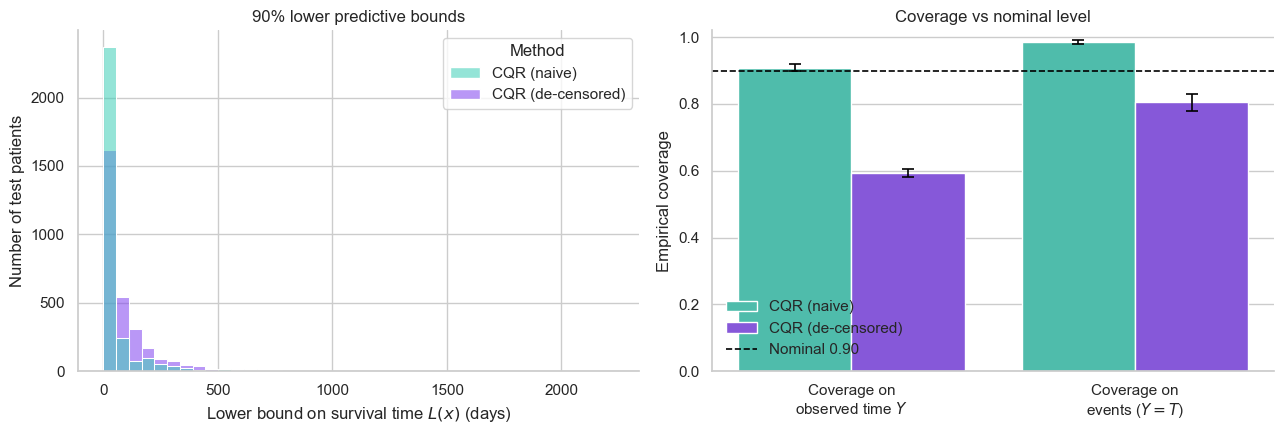

In [28]:
fig, axes = plot_conformal_results(
    results_cqr=results_cqr,
    results_decensored=results_dec,
    lpb_cqr=lpb_cqr,
    lpb_decensored=lpb_dec,
    alpha=alpha_conf,
    colors=("#3DCEB7", "#8042EF")
)